# Quantitative Metrics of Time-Series Benchmark

In [70]:
selected_runs = [
    # Seasonal Naive
    "baseline-seasonal-naive",

    # Autogluon (without Chronos)
    "baseline-autogluon-no-chronos",     

    # "tabpfn-ar",
    "tabpfn-ts-naive",
    # "tabpfn-ts-sincos",
    # "tabpfn-ts-sincos-timedecomp",
    # "tabpfn-ts-ar",
    # "tabpfn-ts-diff",
    # "tabpfn-ts-sincos-timedecomp-new",
    # "tabpfn-ts-sincos-timedecomp-ext",
    # "tabpfn-ts-sincos-timedecomp-quantile",
    "tabpfn-ts-comp",
    "tabpfn-ts-period",
    "tabpfn-ts-linear-comp",
    "tabpfn-ts-linear-sincos",
    "tabpfn-ts-linear-sincos-comp-period",
    # "tabpfn-ts-sp-comp",
    # "tabpfn-ts-sp-linear-sincos-comp-period",
    # "tabpfn-ts-linear-quadratic-comp",
    # "tabpfn-ts-linear-quadratic-sincos-comp-period",
    "tabpfn-ts-linear-sincos-comp-periodsc",
    "tabpfn-ts-linear-sincos-comp",
    "tabpfn-ts-sincos",
    "tabpfn-ts-linear-comp-period",
    "tabpfn-ts-comp-period",
]

## Data Extraction / Preparation

### Pull Results from AGTS Paper

In [71]:
frameworks_to_pull = [
    # 'AutoARIMA', 
    # 'AutoETS',
    # 'AutoPyTorch',
    # 'AutoTheta',
    # 'DeepAR',
    # 'StatEnsemble',
    # 'TFT'
]

In [72]:
import pandas as pd

# Read the CSV file into a DataFrame
csv_file_path = "./agts_benchmark_results.csv"
agts_res = pd.read_csv(csv_file_path)

# Display the first few rows of the DataFrame to verify
agts_res.framework.unique()


array(['AutoARIMA', 'AutoETS', 'AutoGluon_bestquality',
       'AutoGluon_NoDeepModels', 'AutoGluon_NoEnsemble',
       'AutoGluon_NoStatModels', 'AutoGluon_NoTreeModels', 'AutoPyTorch',
       'AutoTheta', 'DeepAR', 'SeasonalNaive', 'StatEnsemble', 'TFT'],
      dtype=object)

In [73]:
agts_res = agts_res[['framework', 'task', 'mase', 'wql', 'predict_duration', 'training_duration']]
agts_res = agts_res[agts_res['framework'].isin(frameworks_to_pull)]

# Group by 'framework' and 'task' and calculate the mean of 'mase', 'wql', 'predict_duration', and 'training_duration' across different seeds
agts_res_avg = agts_res.groupby(['framework', 'task']).agg({
    'mase': 'mean',
    'wql': 'mean',
    'predict_duration': 'mean',
    'training_duration': 'mean'
}).reset_index()

### Our Evaluation Runs

In [74]:
import wandb

# Initialize API (make sure you're logged in or set the API key)
wandb.login()

# Replace with your entity, project, and run ID
api = wandb.Api()

# Get all runs of the project that didn't crash
runs = api.runs(
    "rl-sunflower/tabpfn-time-series",
    # filters={"$and": [{"state": "finished"}, {"group": {"$in": ["11546127", "11548929"]}}]}
    filters={"tags": {"$in": selected_runs}},   
)


In [75]:
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd

def fetch_run_data(run):
    history = run.history()
    
    if len(history) > 1:
        # get the first row
        history = history.iloc[-1:]
    return history

# time the following code
import time
start = time.time()

all_runs_data = []
with ThreadPoolExecutor(max_workers=16) as executor:  # Adjust 'max_workers' based on your network conditions
    futures = [executor.submit(fetch_run_data, run) for run in runs]
    for future in tqdm(as_completed(futures), total=len(futures)):
        all_runs_data.append(future.result())

df_all_runs = pd.concat(all_runs_data)
print("df_all_runs.shape:", df_all_runs.shape)

print(f"Time taken: {time.time() - start:.2f} seconds")


100%|██████████| 270/270 [00:05<00:00, 45.54it/s]


df_all_runs.shape: (270, 27)
Time taken: 7.68 seconds


In [76]:
import numpy as np

# Preprocess data (convert to float, NaN value -> inf)
numerical_cols = ['mase', 'wql', 'predict_duration', 'training_duration', 'result']
for col in numerical_cols:
    df_all_runs[col] = df_all_runs[col].astype(float)
    # df_all_runs[col] = df_all_runs[col].fillna(float('inf')).replace([float('inf'), np.nan], np.nan).astype(float)

df_all_runs.dropna(subset=['result'], inplace=True)

# Get relevant columns only
df_all_runs = df_all_runs[['framework', 'task', 'mase', 'wql', 'predict_duration', 'training_duration', 'seed']]
df_all_runs['seed'] = df_all_runs['seed'].astype(int)

In [77]:
framework_task_seeds = df_all_runs.groupby(['framework', 'task'])['seed'].apply(list).reset_index()
framework_task_seeds.columns = ['framework', 'task', 'seeds']
framework_task_seed_pivot = framework_task_seeds.pivot(index='framework', columns='task', values='seeds').transpose()
framework_task_seed_pivot

framework,AutoGluon,SeasonalNaive,TabPFN-TS,TabPFN-TS-Comp,TabPFN-TS-Comp-Period,TabPFN-TS-Linear-Comp,TabPFN-TS-Linear-Comp-Period,TabPFN-TS-Linear-SinCos,TabPFN-TS-Linear-SinCos-Comp,TabPFN-TS-Linear-SinCos-Comp-Period,TabPFN-TS-Linear-SinCos-Comp-PeriodSC,TabPFN-TS-Period,TabPFN-TS-SinCos
task,,,,,,,,,,,,,
car_parts,[0],[0],"[1, 0]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cif_2016,[0],[0],"[1, 0]",[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]
covid_deaths,[0],[0],"[1, 0]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
electricity_hourly,[0],[0],"[1, 0]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
electricity_weekly,[0],[0],"[1, 0]",[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]
fred_md,[0],[0],"[1, 0]",[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]
hospital,[0],[0],"[1, 0]",[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]
kdd_cup_2018,[0],[0],"[1, 0]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
m1_monthly,[0],[0],"[1, 0]",[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]


In [78]:
if 'agts_res_avg' in locals():
    agts_res_avg = agts_res_avg[agts_res_avg['task'].isin(df_all_runs['task'])]
    df_all_runs = pd.concat([df_all_runs, agts_res_avg], ignore_index=True)
    
df_all_runs['total_duration'] = df_all_runs['predict_duration'] + df_all_runs['training_duration']
df_all_runs.drop(columns=['predict_duration', 'training_duration'], inplace=True)


# Sort by framework and task
df_all_runs = df_all_runs.sort_values(by=['framework', 'task'])

# Drop index
df_all_runs.reset_index(drop=True, inplace=True)

In [79]:
df_all_runs = df_all_runs.groupby(['framework', 'task']).agg({
    'mase': 'mean',
    'wql': 'mean',
    'total_duration': 'mean',
}).reset_index()

# Calculation

### Utils Function

In [80]:
import numpy as np
import scipy.stats as st
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import t


def plot_metric_against_framework(df, metric, annot_format=".2f"):
    df_pivot = df.pivot(index='framework', columns='task', values=metric)
    plot_heatmap(df_pivot, f"{metric}", "Task", "Framework", annot_format=annot_format)


def plot_heatmap(data, title, xlabel, ylabel, annot_format=".0f", cmap='YlOrRd', annot=None):
    """
    Plots a heatmap for given data.

    Parameters:
    - data: DataFrame containing the data to be plotted.
    - title: str, title of the heatmap.
    - xlabel: str, label for the x-axis.
    - ylabel: str, label for the y-axis.
    - annot_format: str, format string for annotations.
    - cmap: str, colormap used for heatmap.
    - annot: DataFrame or bool, annotations to be shown on the heatmap.
    """
    plt.figure(figsize=(25, 10))
    if annot is None:
        annot = data
    sns.heatmap(data, cmap=cmap, annot=annot, fmt=annot_format, mask=data.isna())
    plt.title(title, fontsize=20)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.grid(False)
    plt.show()


def min_max_scaling(series):
    return (series - series.min()) / (series.max() - series.min())


def diff_to_champion(series):
    return series - series.min()


def get_final_metrics(df):
    """
    Calculate the following metrics for the given dataframe:
    1. Average rescaled score (across all tasks) for each framework
    2. Average rank (across all tasks) for each framework
    3. Champion count (number of times a framework had the best performance across all tasks)

    Parameters:
    df (pd.DataFrame): DataFrame containing the rescaled MASE values for each framework and task.

    Returns:
    pd.DataFrame: DataFrame with 'average_rescaled_score', 'average_rank', and 'champion' for each framework.
    """
    frameworks = df.index
    df_metric = pd.DataFrame(index=frameworks, columns=['average_rescaled_score', 'average_rank', 'champion'])

    df_metric['average_rescaled_score'] = df.mean(axis=1)
    df_metric['average_rank'] = df.rank(axis=0, na_option='keep').mean(axis=1)
    df_metric['champion'] = (df.rank(axis=0, method='min', ascending=True) == 1).sum(axis=1)
    
    return df_metric.sort_values(by='average_rescaled_score')


def compute_mean_and_confidence_interval(df_pivot, confidence_level=0.95):
    mean = df_pivot.mean(axis=1)
    std = df_pivot.std(axis=1)
    confidence_interval = t.ppf(confidence_level, df_pivot.shape[1] - 1) * (std / np.sqrt(df_pivot.shape[1]))
    return mean, confidence_interval


def plot_mean_and_confidence_interval(df_pivot, confidence_level=0.95, title="dummy-title"):
    mean_score, confidence_interval = compute_mean_and_confidence_interval(df_pivot, confidence_level)

    # Sort the data by mean value
    sorted_indices = mean_score.argsort()
    sorted_mean = mean_score[sorted_indices]
    sorted_confidence_interval = confidence_interval[sorted_indices]
    
    # Plot the mean and confidence interval
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = sorted_mean.plot(kind='bar', yerr=sorted_confidence_interval, ax=ax, capsize=4, color='skyblue', edgecolor='black')
    
    # Add value annotations on the bars
    for bar in bars.patches:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', 
                    xy=(bar.get_x() + bar.get_width() / 2, height), 
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points", 
                    ha='left', va='bottom')

    # Customize the plot
    ax.set_title(f'{title}\n ({confidence_level * 100}% Confidence Interval)')
    ax.set_xlabel('Framework')
    ax.set_ylabel(f'Mean')
    ax.grid(True, linestyle='--', alpha=0.7)

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [81]:
# Calculate normalized MASE and WQL (one entry for each task, normalized across framework)
df_all_runs['normalized_mase'] = df_all_runs.groupby('task')['mase'].transform(min_max_scaling)
df_all_runs['normalized_wql'] = df_all_runs.groupby('task')['wql'].transform(min_max_scaling)

# Calculate MASE and WQL normalized by SeasonalNaive for each task
seasonal_naive_mase = df_all_runs[df_all_runs['framework'] == 'SeasonalNaive'].set_index('task')['mase']
df_all_runs['mase_normalized_by_seasonal_naive'] = df_all_runs.apply(
    lambda row: row['mase'] / seasonal_naive_mase.loc[row['task']] 
    if row['task'] in seasonal_naive_mase.index else np.nan, 
    axis=1
)
seasonal_naive_wql = df_all_runs[df_all_runs['framework'] == 'SeasonalNaive'].set_index('task')['wql']
df_all_runs['wql_normalized_by_seasonal_naive'] = df_all_runs.apply(
    lambda row: row['wql'] / seasonal_naive_wql.loc[row['task']] 
    if row['task'] in seasonal_naive_wql.index else np.nan, 
    axis=1
)

exclude_dataset_for_eval = [
    # huge
    'vehicle_trips',
    'pedestrian_counts',
    'electricity_hourly',
    'm4_daily',

    # medium
    'kdd_cup_2018',
    'car_parts',
    'm3_monthly',
]

mase_eval = df_all_runs[~df_all_runs['task'].isin(exclude_dataset_for_eval)]
wql_eval = df_all_runs[~df_all_runs['task'].isin(exclude_dataset_for_eval)]

mase_eval_pivot = mase_eval.pivot(index='framework', columns='task', values='mase_normalized_by_seasonal_naive')
wql_eval_pivot = wql_eval.pivot(index='framework', columns='task', values='wql_normalized_by_seasonal_naive')

# Results

### MASE (raw)

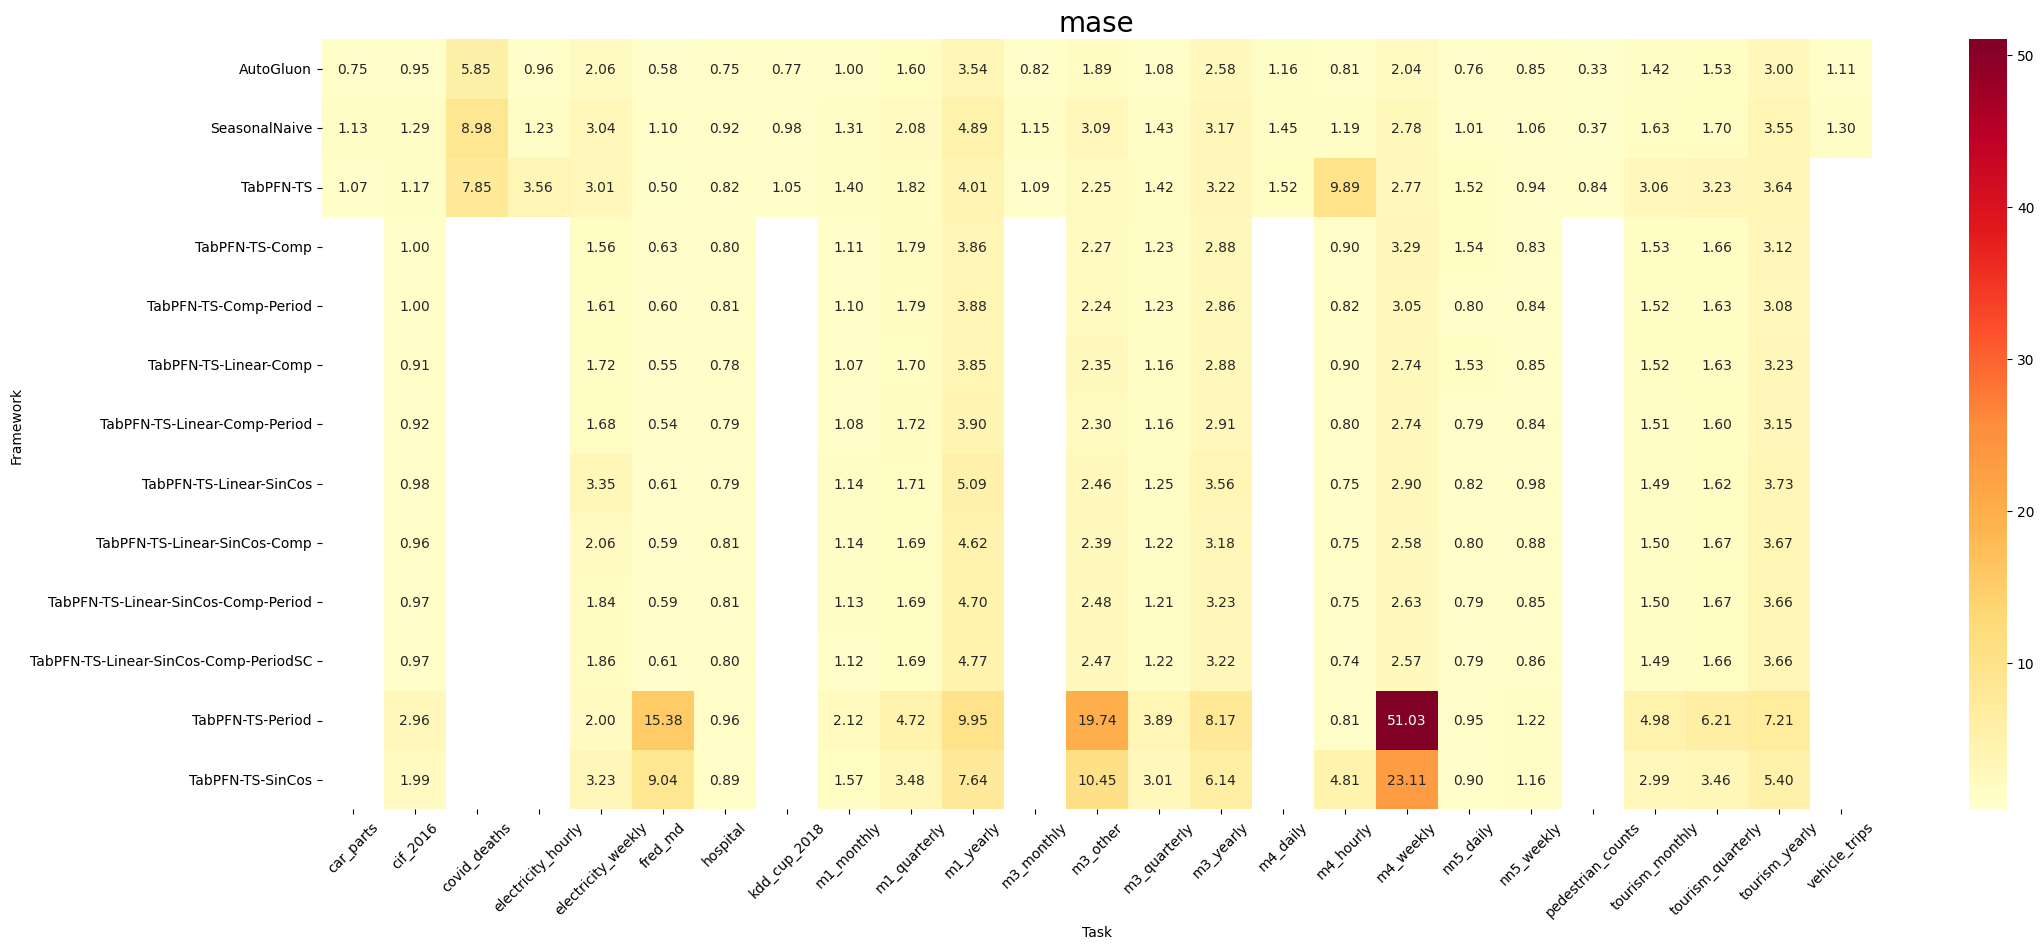

In [82]:
plot_metric_against_framework(df_all_runs, 'mase', annot_format=".2f")

### MASE (normalized by SeasonalNaive)

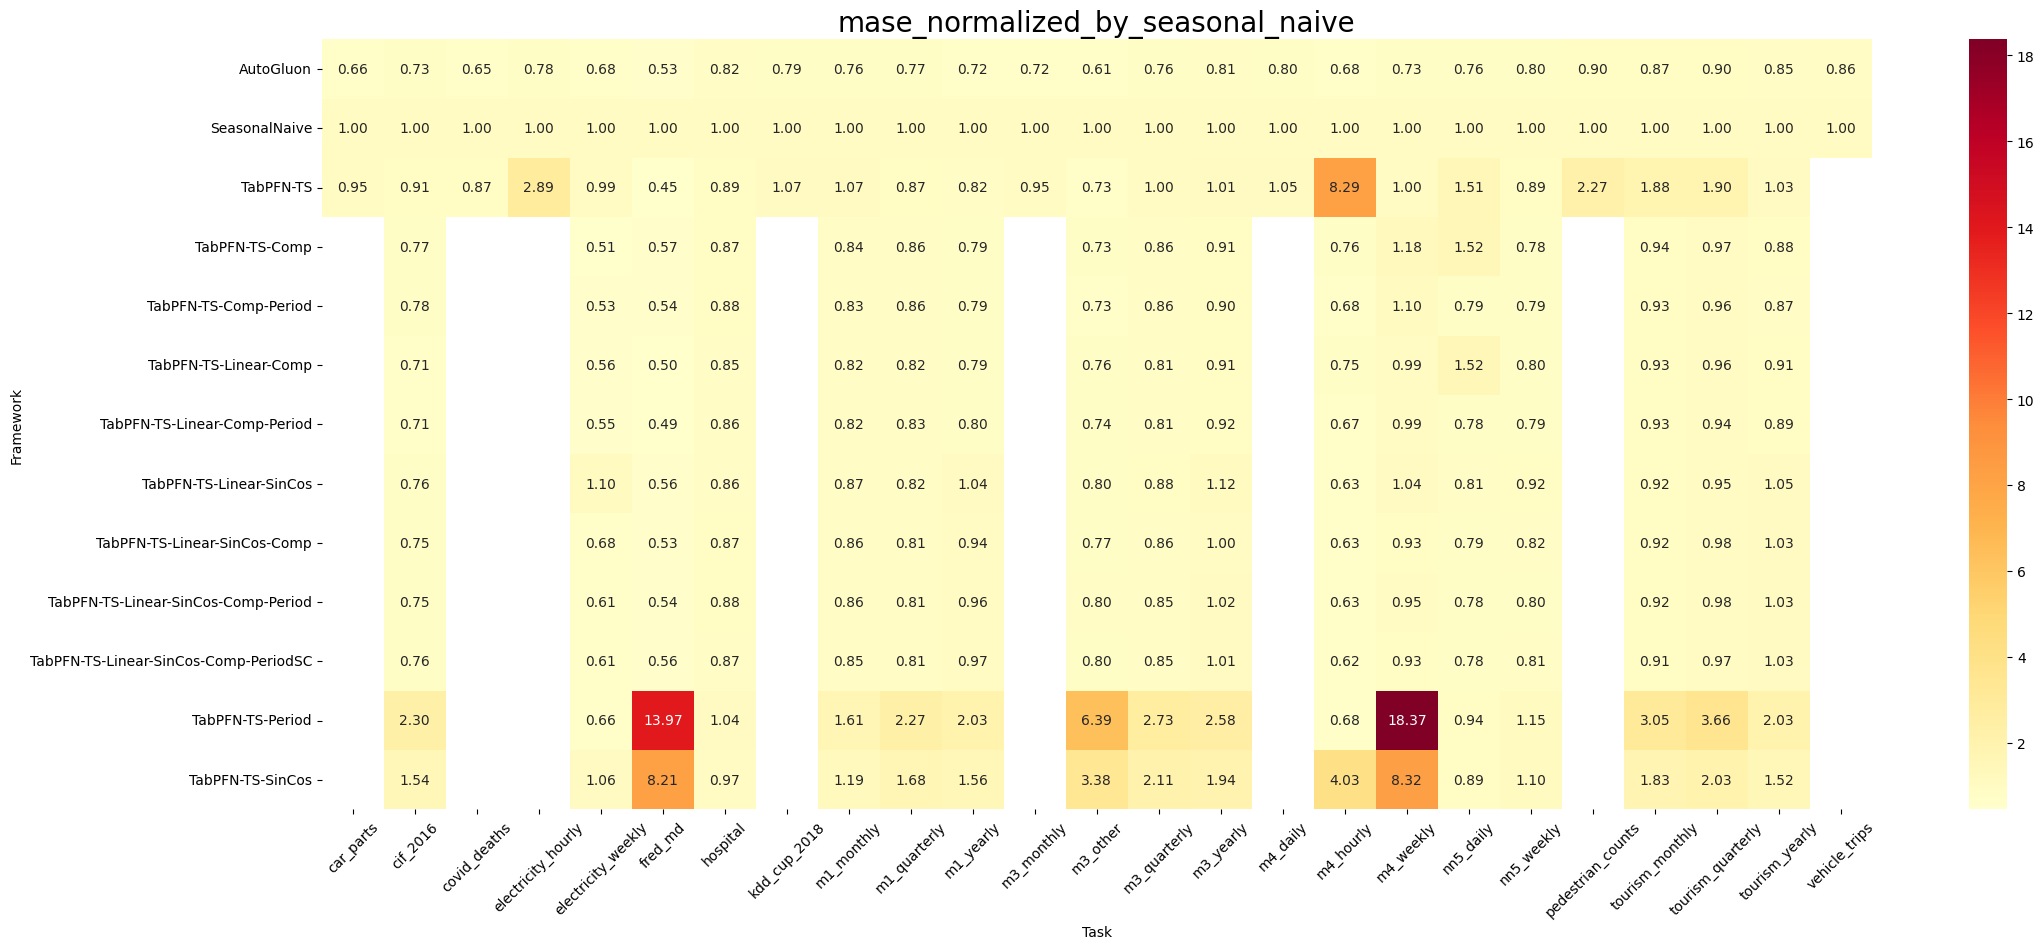

In [83]:
plot_metric_against_framework(df_all_runs, 'mase_normalized_by_seasonal_naive', annot_format=".2f")

### Normalized MASE (for Point Forecasting)

In [84]:
# import numpy as np

# df_norm_mase_pivot = df_all_runs.pivot(index='framework', columns='task', values='normalized_mase')
# df_norm_mase_pivot = df_norm_mase_pivot.loc[:, ~df_norm_mase_pivot.columns.isin(exclude_dataset_for_metric)]

# plot_heatmap(df_norm_mase_pivot, f"Normalized MASE\n(excluded {exclude_dataset_for_metric})", "Task", "Framework", annot_format=".2f")



### WQL (raw)

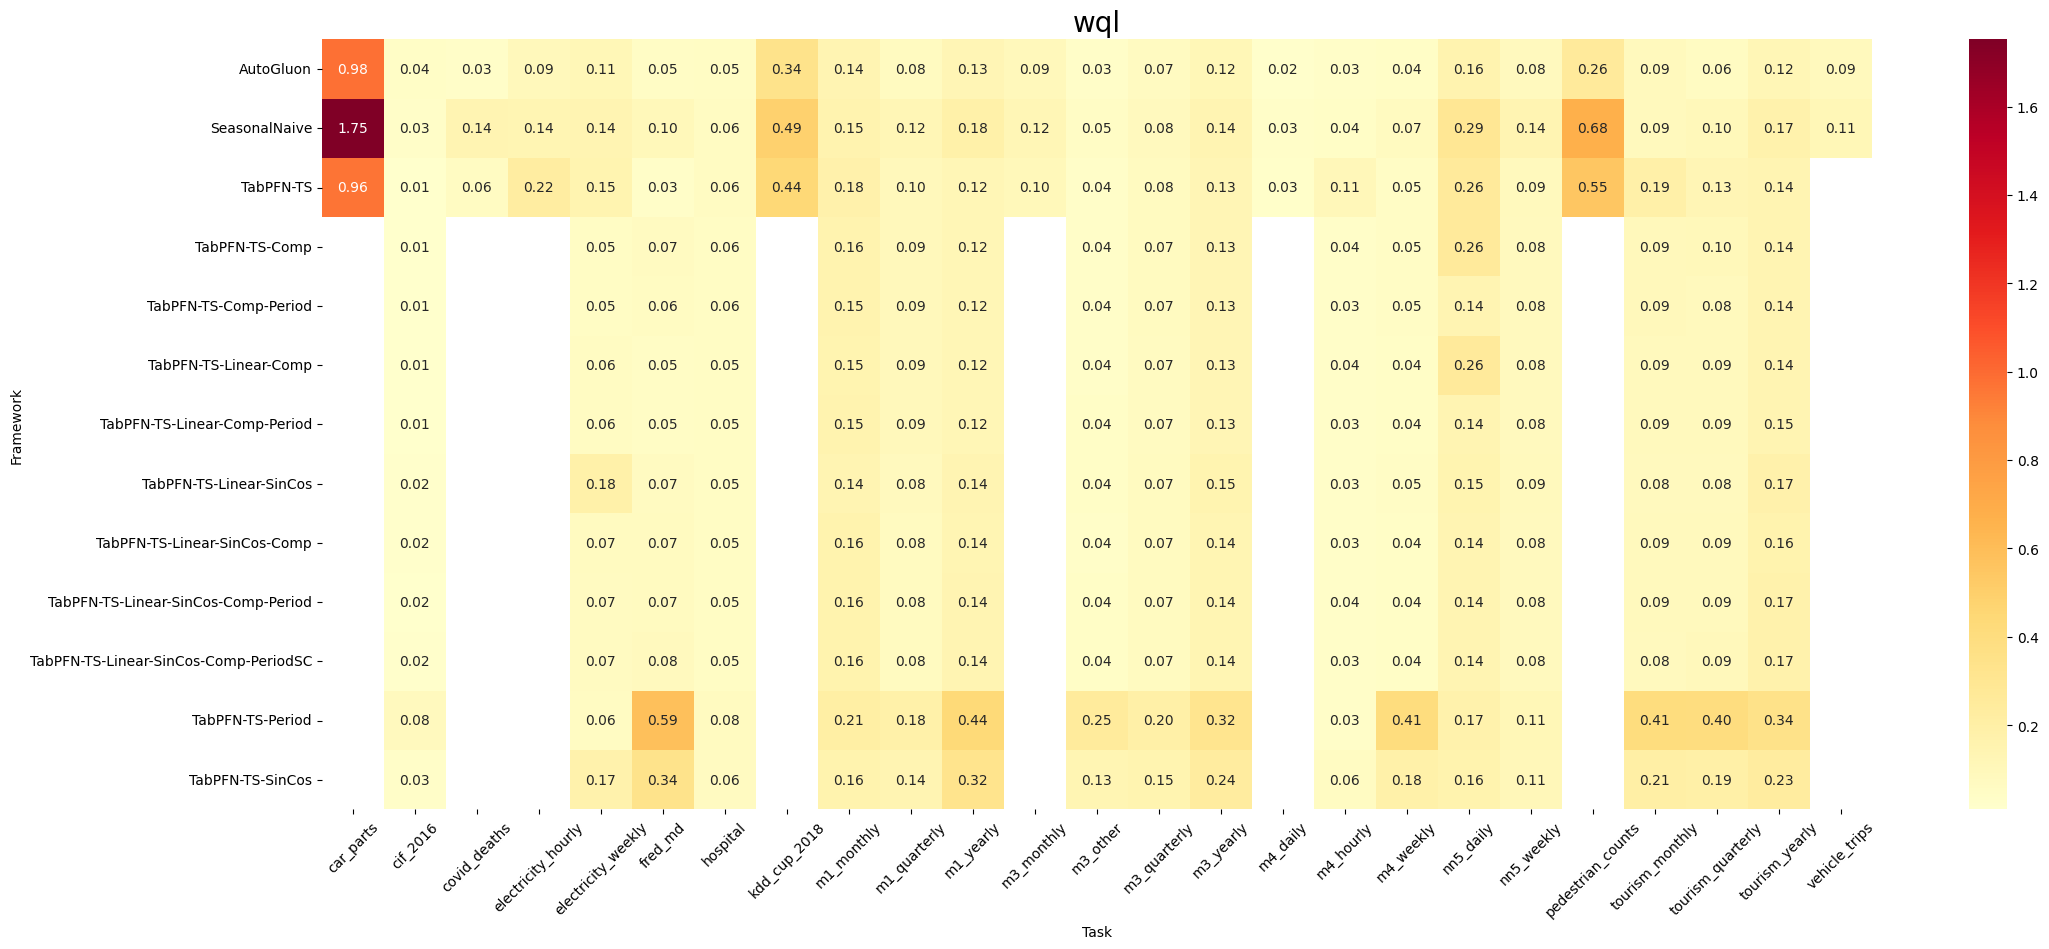

In [85]:
plot_metric_against_framework(df_all_runs, 'wql', annot_format=".2f")

### WQL (normalized by SeasonalNaive)

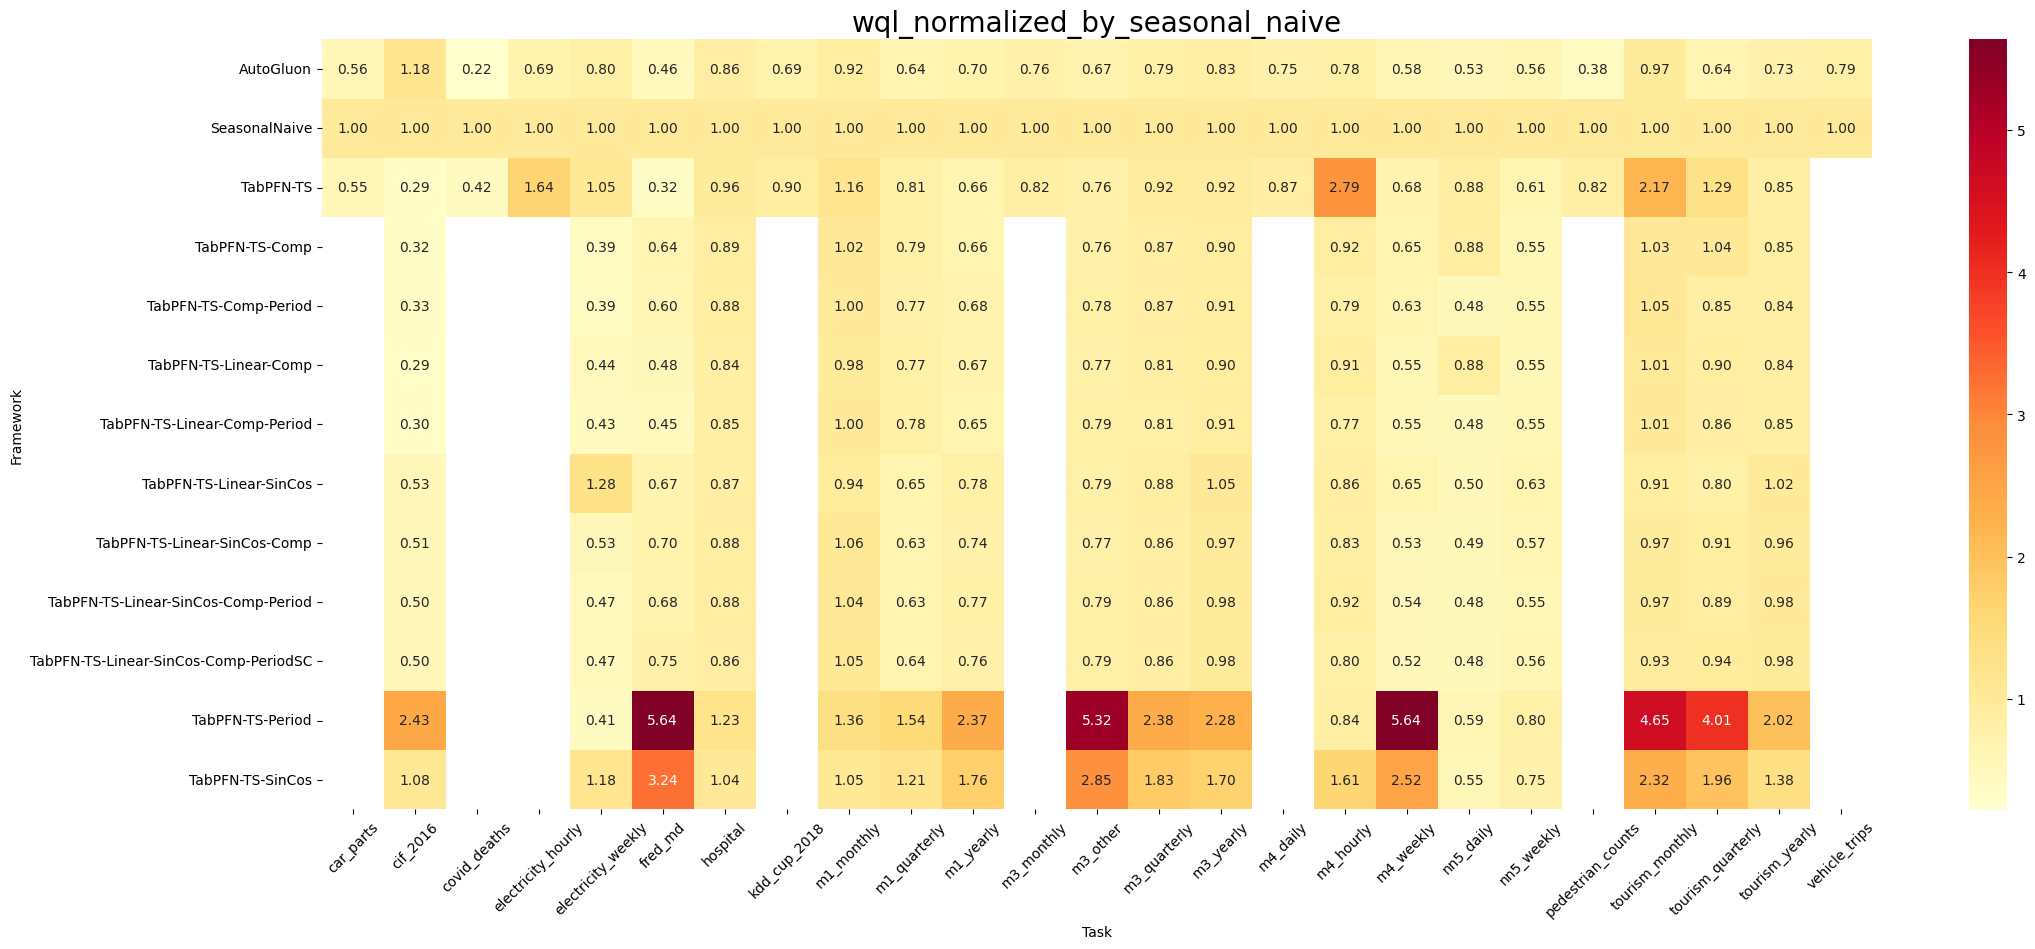

<function __main__.plot_mean_and_confidence_interval(df_pivot, confidence_level=0.95, title='dummy-title')>

In [86]:
plot_metric_against_framework(df_all_runs, 'wql_normalized_by_seasonal_naive', annot_format=".2f")
plot_mean_and_confidence_interval

## Aggregated Metrics (for Point Forecasting)

In [87]:
get_final_metrics(mase_eval_pivot)

,average_rescaled_score,average_rank,champion
framework,,,
AutoGluon,0.746487,2.277778,13
TabPFN-TS-Linear-Comp-Period,0.795105,4.000000,0
TabPFN-TS-Comp-Period,0.812780,5.529412,0
TabPFN-TS-Linear-SinCos-Comp-PeriodSC,0.832750,5.588235,1
TabPFN-TS-Linear-SinCos-Comp-Period,0.833067,6.058824,0
TabPFN-TS-Linear-SinCos-Comp,0.835070,6.117647,0
TabPFN-TS-Linear-Comp,0.845909,4.647059,1
TabPFN-TS-Comp,0.868033,6.470588,2
TabPFN-TS-Linear-SinCos,0.890778,7.764706,0


In [88]:
get_final_metrics(wql_eval_pivot)

,average_rescaled_score,average_rank,champion
framework,,,
TabPFN-TS-Linear-Comp-Period,0.708717,3.705882,4
AutoGluon,0.713459,3.833333,7
TabPFN-TS-Comp-Period,0.728195,5.058824,0
TabPFN-TS-Linear-Comp,0.741036,4.705882,1
TabPFN-TS-Linear-SinCos-Comp-PeriodSC,0.756573,6.058824,1
TabPFN-TS-Linear-SinCos-Comp,0.758816,6.352941,0
TabPFN-TS-Linear-SinCos-Comp-Period,0.760124,6.058824,1
TabPFN-TS-Comp,0.775372,6.411765,1
TabPFN-TS-Linear-SinCos,0.811511,7.352941,1


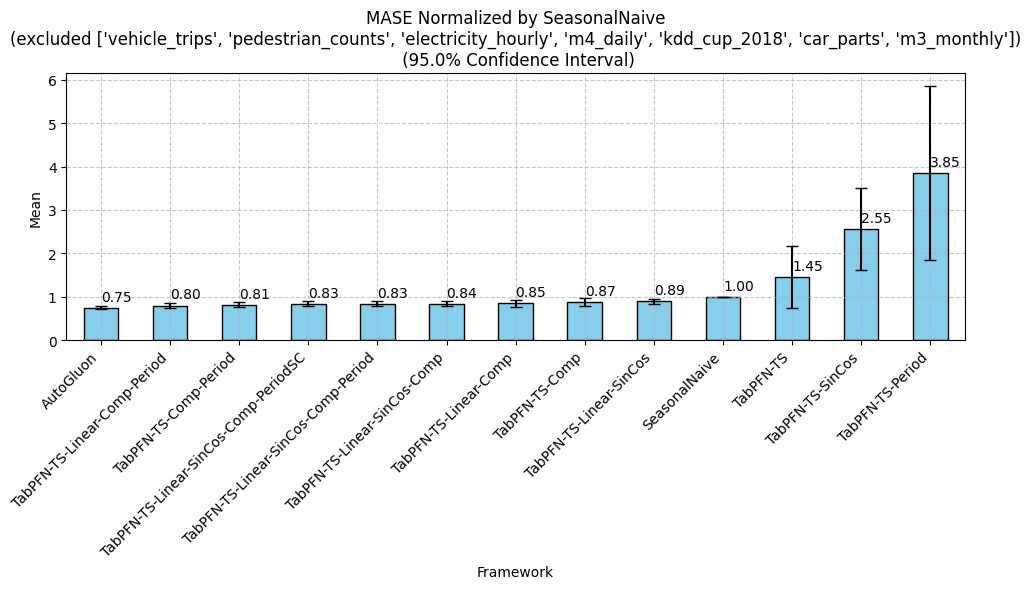

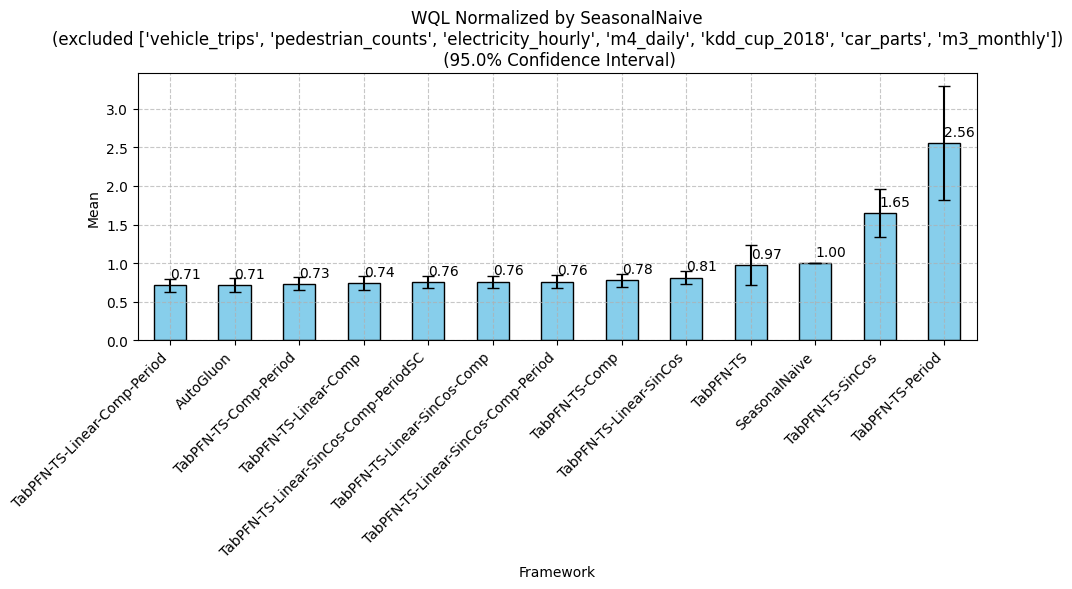

In [89]:
plot_mean_and_confidence_interval(mase_eval_pivot, confidence_level=0.95, title=f"MASE Normalized by SeasonalNaive\n(excluded {exclude_dataset_for_eval})")
plot_mean_and_confidence_interval(wql_eval_pivot, confidence_level=0.95, title=f"WQL Normalized by SeasonalNaive\n(excluded {exclude_dataset_for_eval})")

# Others

In [90]:
mase_normalized_pivot = df_all_runs.pivot(index='framework', columns='task', values='mase_normalized_by_seasonal_naive')
mase_normalized_pivot

task,car_parts,cif_2016,covid_deaths,electricity_hourly,electricity_weekly,fred_md,hospital,kdd_cup_2018,m1_monthly,m1_quarterly,...,m4_daily,m4_hourly,m4_weekly,nn5_daily,nn5_weekly,pedestrian_counts,tourism_monthly,tourism_quarterly,tourism_yearly,vehicle_trips
framework,,,,,,,,,,,,,,,,,,,,,
AutoGluon,0.663397,0.733759,0.651786,0.777108,0.678329,0.525982,0.815256,0.792584,0.761309,0.771889,...,0.799543,0.682169,0.732773,0.755336,0.798286,0.897658,0.873564,0.900559,0.845980,0.855732
SeasonalNaive,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
TabPFN-TS,0.951703,0.910299,0.874184,2.892766,0.991905,0.450713,0.893411,1.073259,1.067784,0.874554,...,1.047704,8.291210,0.997190,1.505013,0.887338,2.269413,1.878003,1.903958,1.025214,NaN
TabPFN-TS-Comp,NaN,0.773869,NaN,NaN,0.513659,0.568721,0.871452,NaN,0.841699,0.862332,...,NaN,0.757100,1.183473,1.519668,0.784431,NaN,0.935957,0.974155,0.878215,NaN
TabPFN-TS-Comp-Period,NaN,0.776381,NaN,NaN,0.529704,0.542436,0.878170,NaN,0.833148,0.861697,...,NaN,0.683482,1.096727,0.789503,0.786031,NaN,0.931996,0.956868,0.867087,NaN
TabPFN-TS-Linear-Comp,NaN,0.708447,NaN,NaN,0.564904,0.500453,0.852449,NaN,0.815909,0.818025,...,NaN,0.754915,0.986580,1.517275,0.795191,NaN,0.932695,0.960877,0.909620,NaN
TabPFN-TS-Linear-Comp-Period,NaN,0.711983,NaN,NaN,0.553100,0.486310,0.862971,NaN,0.818161,0.828446,...,NaN,0.674027,0.985871,0.784397,0.786445,NaN,0.926797,0.940888,0.886307,NaN
TabPFN-TS-Linear-SinCos,NaN,0.759756,NaN,NaN,1.104275,0.558164,0.859540,NaN,0.868524,0.823657,...,NaN,0.630546,1.043733,0.814612,0.919570,NaN,0.915270,0.954043,1.050923,NaN
TabPFN-TS-Linear-SinCos-Comp,NaN,0.746842,NaN,NaN,0.678217,0.534612,0.874992,NaN,0.864903,0.812706,...,NaN,0.630057,0.928729,0.787923,0.824214,NaN,0.919825,0.982513,1.032984,NaN


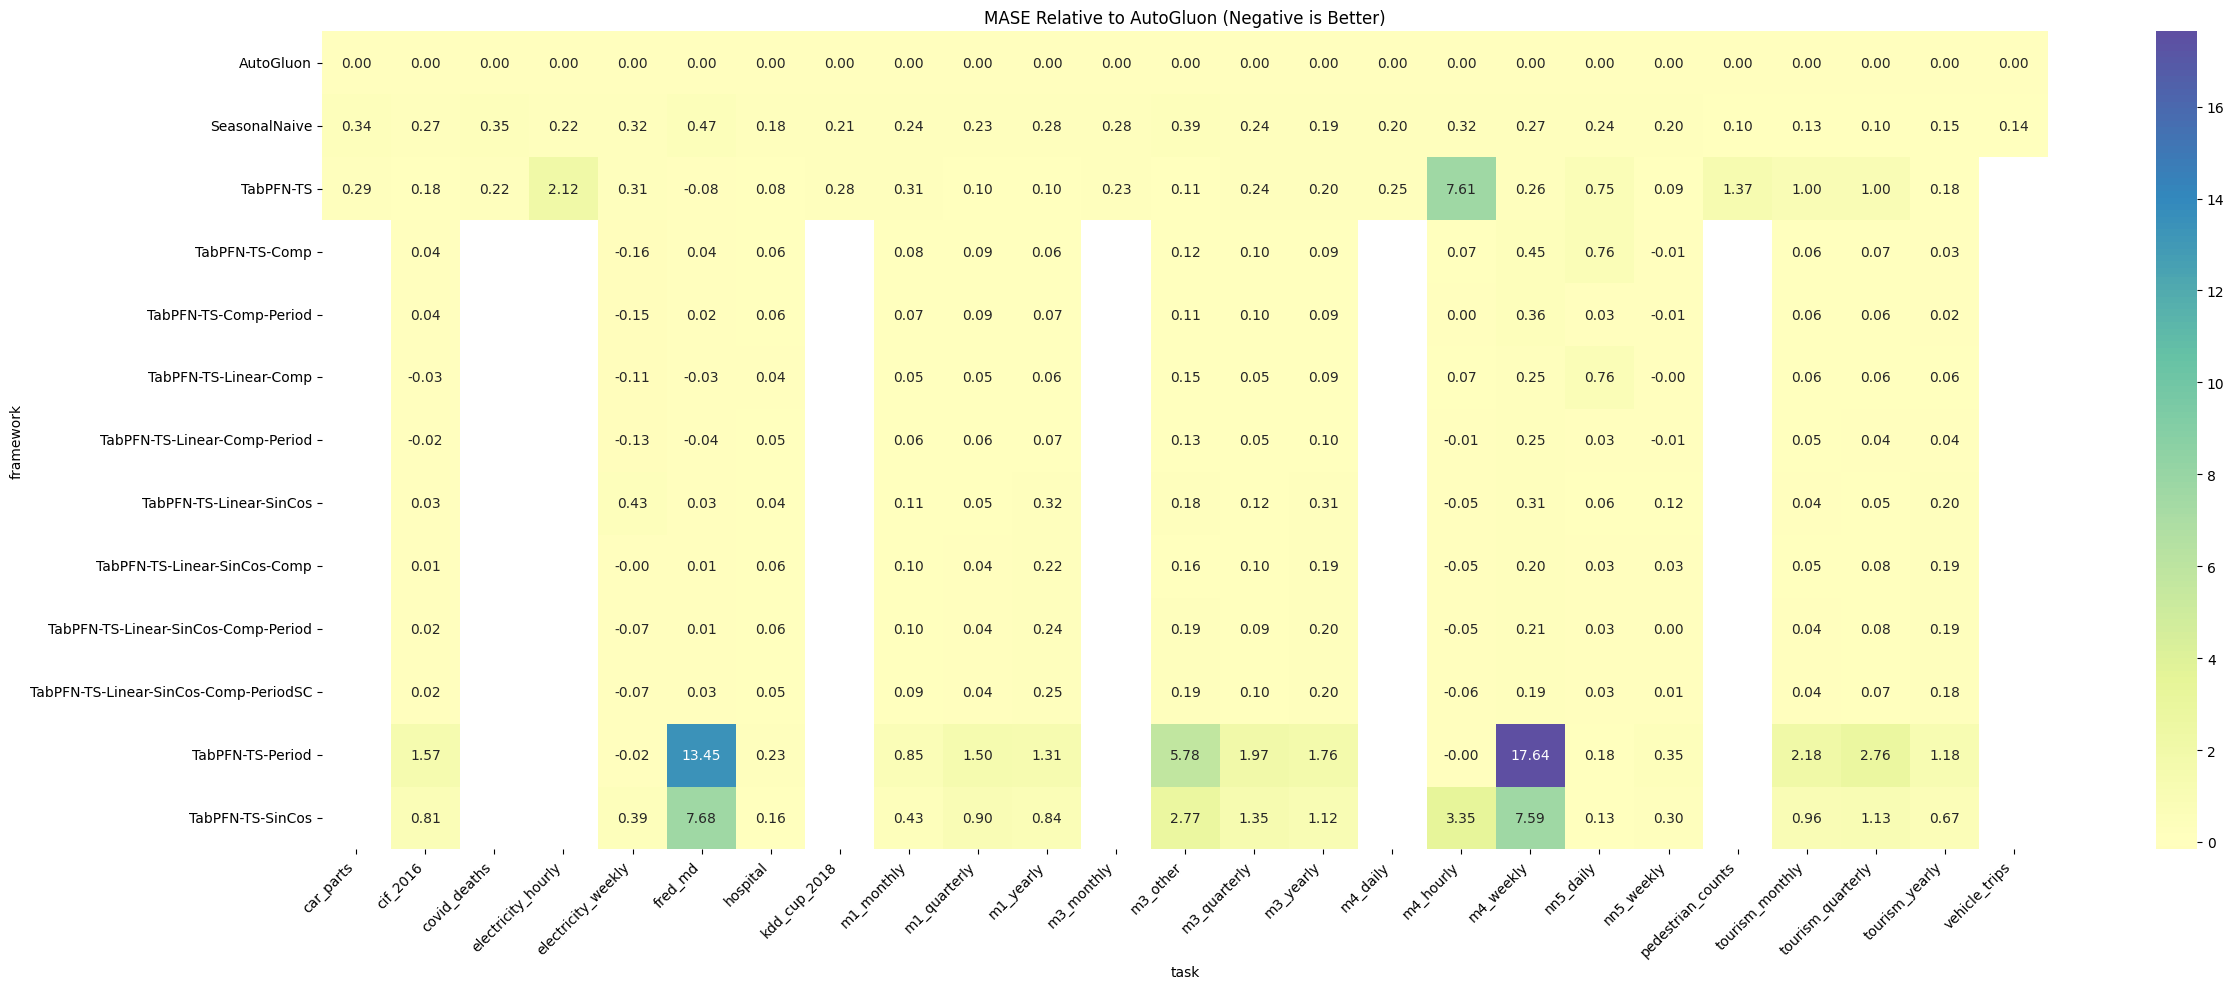

In [91]:
# Subtract AutoGluon's values from all entries
autogluon_values = mase_normalized_pivot.loc["AutoGluon"]
mase_normalized_pivot_relative = mase_normalized_pivot.sub(autogluon_values)

# Visualize the relative performance
plt.figure(figsize=(25, 10))
sns.heatmap(mase_normalized_pivot_relative, annot=True, cmap="Spectral", center=0, fmt=".2f")
plt.title("MASE Relative to AutoGluon (Negative is Better)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# autogluon_values


In [92]:
# Plot mean and standard deviation of MASE for each task
mean_mase_per_task = df_mase_pivot.mean(axis=0)
std_mase_per_task = df_mase_pivot.std(axis=0)

# Plot the mean and standard deviation
fig, ax = plt.subplots(figsize=(12, 6))
bars = mean_mase_per_task.plot(kind='bar', yerr=std_mase_per_task, ax=ax, capsize=4, color='lightgreen', edgecolor='black')

# Add value annotations on the bars
for bar in bars.patches:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', 
                xy=(bar.get_x() + bar.get_width() / 2, height), 
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points", 
                ha='center', va='bottom')

# Customize the plot
ax.set_title('Mean and Standard Deviation of MASE for Each Task')
ax.set_xlabel('Task')
ax.set_ylabel('Mean MASE')
ax.grid(True, linestyle='--', alpha=0.7)


NameError: name 'df_mase_pivot' is not defined

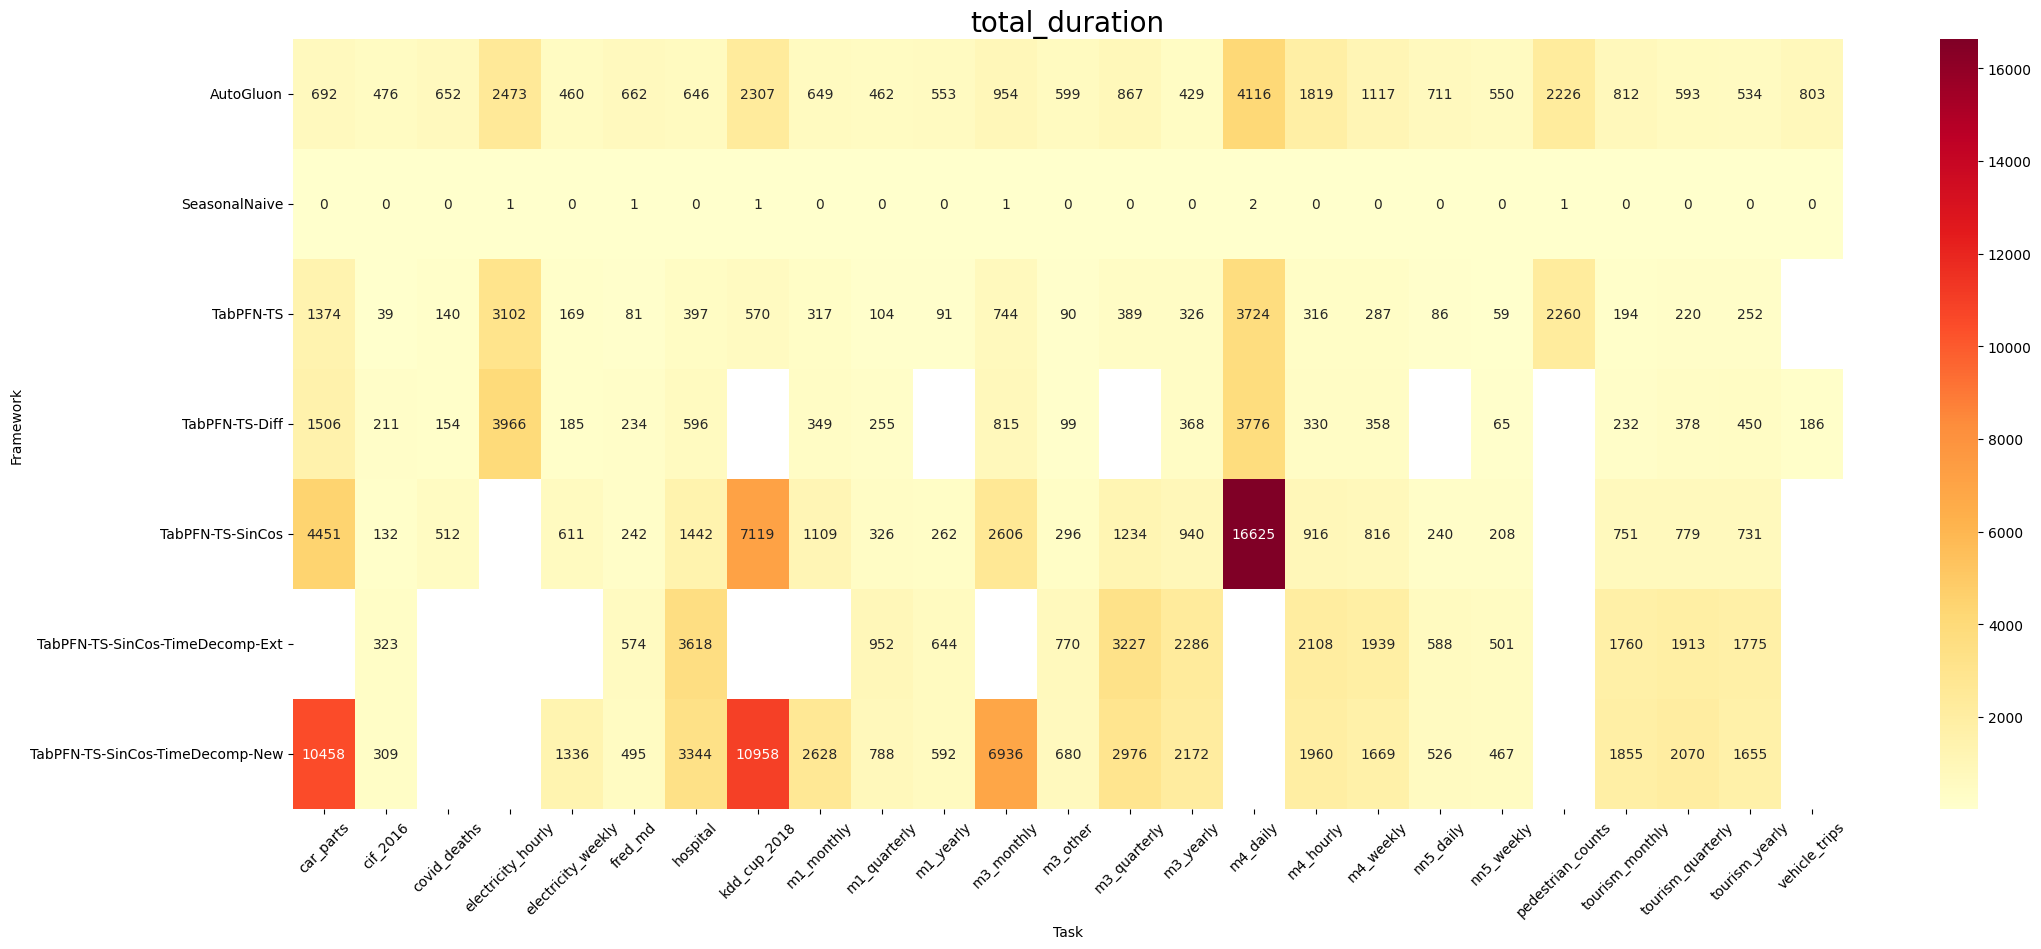

In [ ]:
# Customized annotation (each cell should be value of mase and total duration as a subtext)
df_duration_pivot = df_all_runs.pivot(index='framework', columns='task', values='total_duration')
plot_metric_against_framework(df_all_runs, 'total_duration', annot_format=".0f")